In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
y = np.load("/home/pi/Desktop/Camp2Code/Car/images/y.npy")
y = np.sort(y)
df = pd.DataFrame(data=y)
foo_1 = [val[0] for val in df.value_counts().index]
foo_2 = [val for val in df.value_counts()]
df = pd.DataFrame(data=[foo_1, foo_2], index=["Lenkwinkel", "Häufigkeit"])
df = df.T
df

,Lenkwinkel,Häufigkeit
0,45.0,29.0
1,105.0,27.0
2,108.0,27.0
3,135.0,25.0
4,106.0,24.0
...,...,...
84,81.0,2.0
85,65.0,2.0
86,122.0,2.0
87,60.0,2.0


In [4]:
idx_1 = df["Lenkwinkel"] < 80
idx_2 = df["Lenkwinkel"] > 100
idx_3 = df["Lenkwinkel"] >= 80
idx_4 = df["Lenkwinkel"] <= 100
idx_5 = idx_3 & idx_4

print(f'Die Anzahl der Lenkwinkel nach links: {df[idx_1]["Häufigkeit"].sum()}')
print(f'Die Anzahl der Lenkwinkel nach rechts: {df[idx_2]["Häufigkeit"].sum()}')
print(f'Die Anzahl der Lenkwinkel nach geradeaus: {df[idx_5]["Häufigkeit"].sum()}')
print(f'Anzahl Bilder insgesamt: {len(y)}')

Die Anzahl der Lenkwinkel nach links: 318.0
Die Anzahl der Lenkwinkel nach rechts: 379.0
Die Anzahl der Lenkwinkel nach geradeaus: 149.0
Anzahl Bilder insgesamt: 846


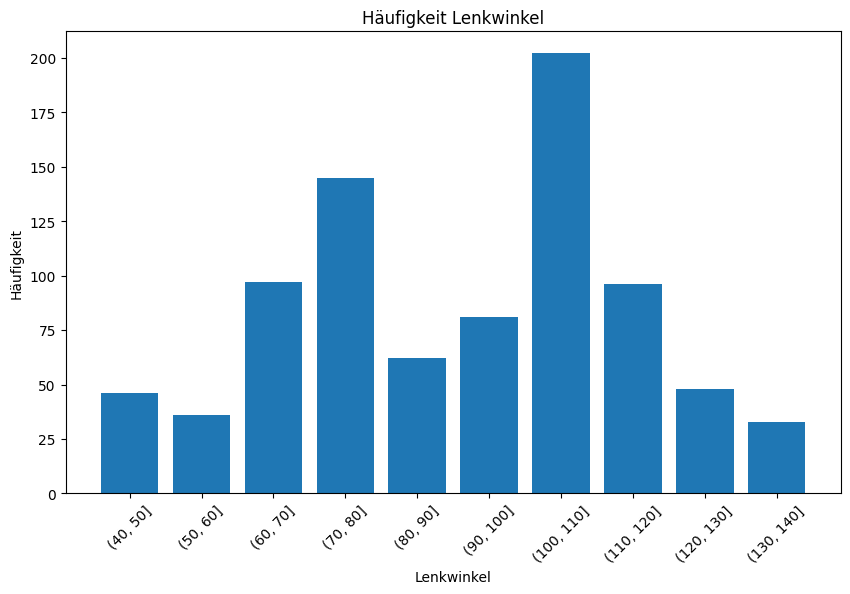

In [5]:
bins = range(40, 141, 10)
df['Lenkwinkel_grp'] = pd.cut(df['Lenkwinkel'], bins=bins)
grouped = df.groupby('Lenkwinkel_grp')['Häufigkeit'].sum().reset_index()
plt.figure(figsize=(10, 6))
plt.bar(grouped['Lenkwinkel_grp'].astype(str), grouped['Häufigkeit'])
plt.xlabel('Lenkwinkel')
plt.ylabel('Häufigkeit')
plt.title('Häufigkeit Lenkwinkel')
plt.xticks(rotation=45)
plt.show()

In [6]:
import tflite_runtime.interpreter as tflite
import cv2
interpreter = tflite.Interpreter(model_path="/home/pi/Desktop/Camp2Code/Car/TFLite_Modell.tflite")
x = np.load("/home/pi/Desktop/Camp2Code/Car/images/x.npy")
y = np.load("/home/pi/Desktop/Camp2Code/Car/images/y.npy")
winkelhalbierende = np.arange(45, 136)
y_pred = []

for img in x:
    frame = img
    frame = frame.astype(np.float32)
    frame = frame.reshape(1, 128, 128, 3)
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    interpreter.allocate_tensors()
    interpreter.set_tensor(input_details[0]['index'], frame)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    mean_angle = output_data[0][0]
    y_pred.append(mean_angle)

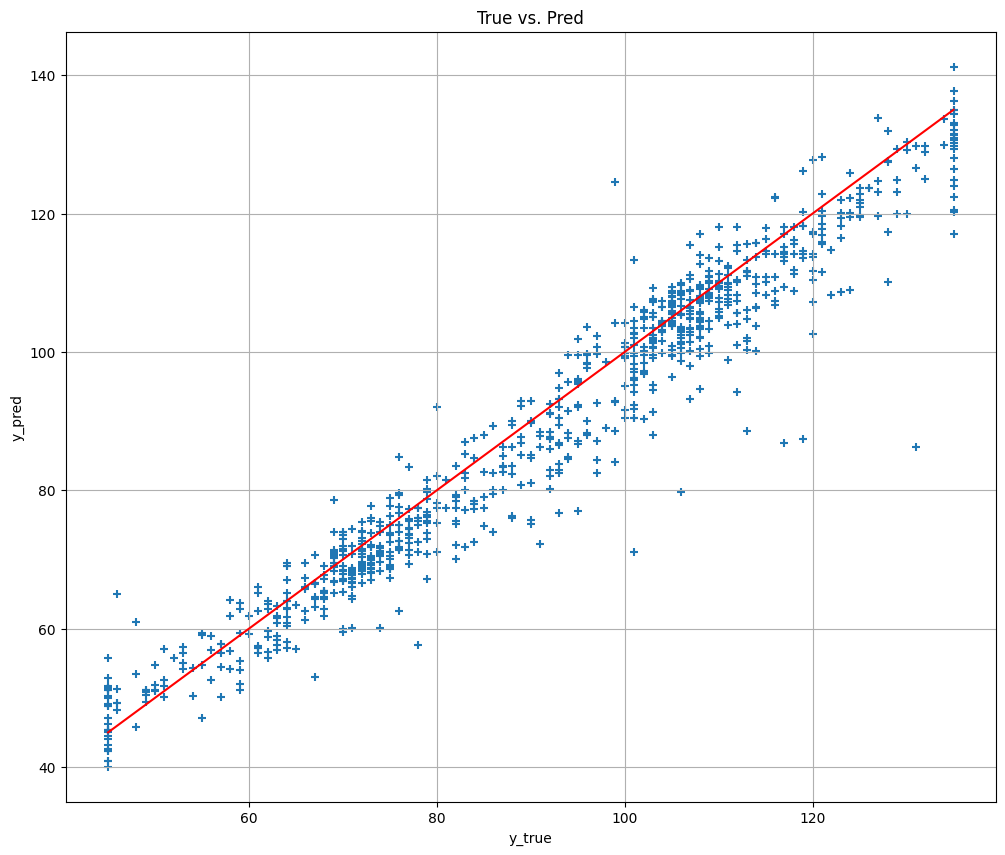

In [7]:
fig, _ = plt.subplots()
fig.set_size_inches(12, 10)
plt.scatter(y, y_pred, marker="+")
plt.plot(winkelhalbierende, winkelhalbierende, "r")
plt.axis("tight")
plt.title("True vs. Pred")
plt.xlabel("y_true")
plt.ylabel("y_pred")
plt.grid()
plt.show()

In [13]:
test = [y_pred-y]
test = np.array(test)
wert = np.argmax(test)
wert

836

In [14]:
frame = x[836]
frame = frame.astype(np.float32)
frame = frame.reshape(1, 128, 128, 3)
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
interpreter.allocate_tensors()
interpreter.set_tensor(input_details[0]['index'], frame)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
mean_angle = output_data[0][0]
mean_angle

124.53957

In [15]:
y[836]

99.0

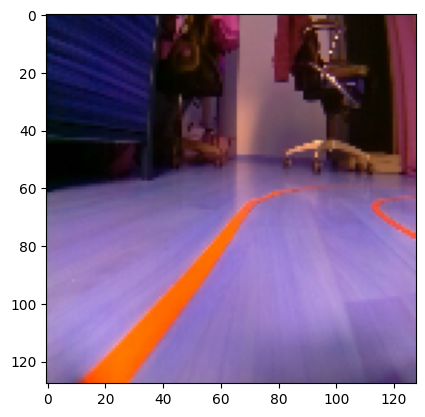

In [16]:
plt.imshow(x[836])